#Task: Determine the eligibility for granting Home loan.
Objective of this notebook is:

1. To understand the patterns in the data.
2. How to Handle the categorical features.
3. How to deal with missing data.
4. Feature Engineering
5. Finding the most important features while taking the decision of granting a loan application.
6. Understanding the Normalization and standardisation of the data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
!gdown --fuzzy "https://drive.google.com/file/d/1KKiz5kBuOGOSZS_Tt8q4lVQX57feqo7G/view?usp=drive_link"

Downloading...
From: https://drive.google.com/uc?id=1KKiz5kBuOGOSZS_Tt8q4lVQX57feqo7G
To: /content/train.csv
100% 38.0k/38.0k [00:00<00:00, 72.5MB/s]


In [3]:
df = pd.read_csv("train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df = df.drop('Loan_ID',axis=1)

In [ ]:
df.describe(include = ['object'])

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,599,614,582,614,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,489,398,345,480,500,233,422


In [8]:
df.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


#Basic Visualization Univariate


In [9]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


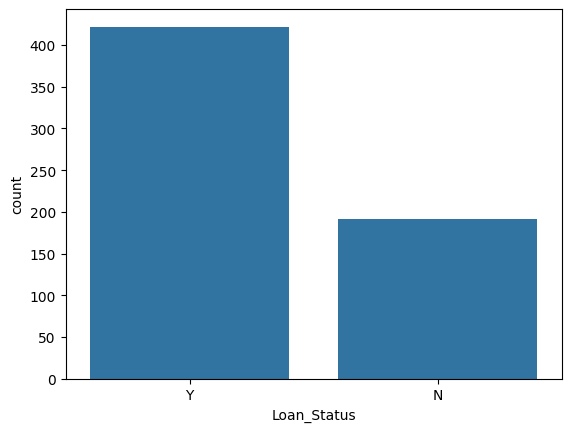

In [10]:
sns.countplot(data = df,x = 'Loan_Status')
plt.show()

sublot(rows, coluns,fig) so if we mention subplot(121) then it means 1 row 2 column, 1st plot

<Axes: >

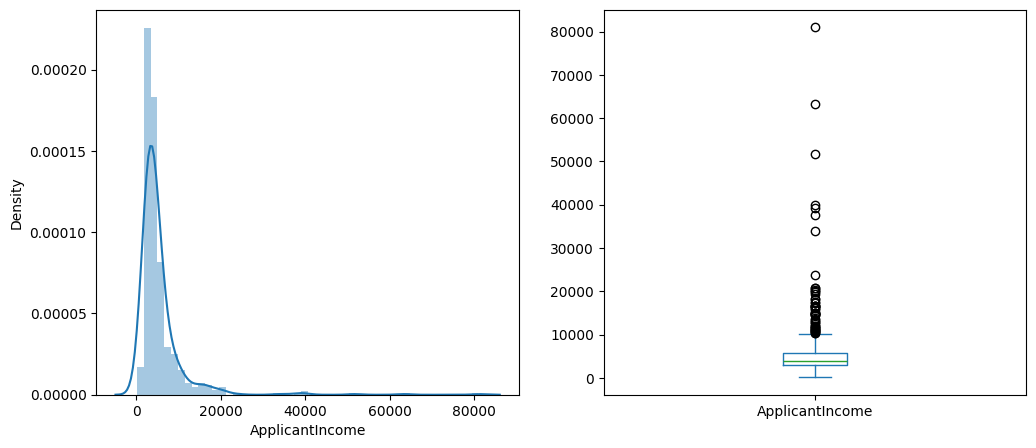

In [11]:
plt.subplot(121)
sns.distplot(df['ApplicantIncome'])

plt.subplot(122)
df['ApplicantIncome'].plot.box(figsize =(12,5))

Here in these both plot we can see there are outliers in ApplicantIncome,most values are between 0 to 20000, and plot has right skewness, to make normal distribution we have to take log of these valiues


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

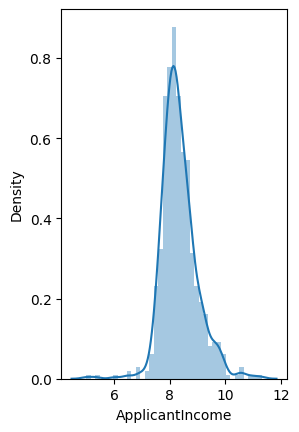

In [ ]:
plt.subplot(121)
sns.distplot(np.log(df['ApplicantIncome']))

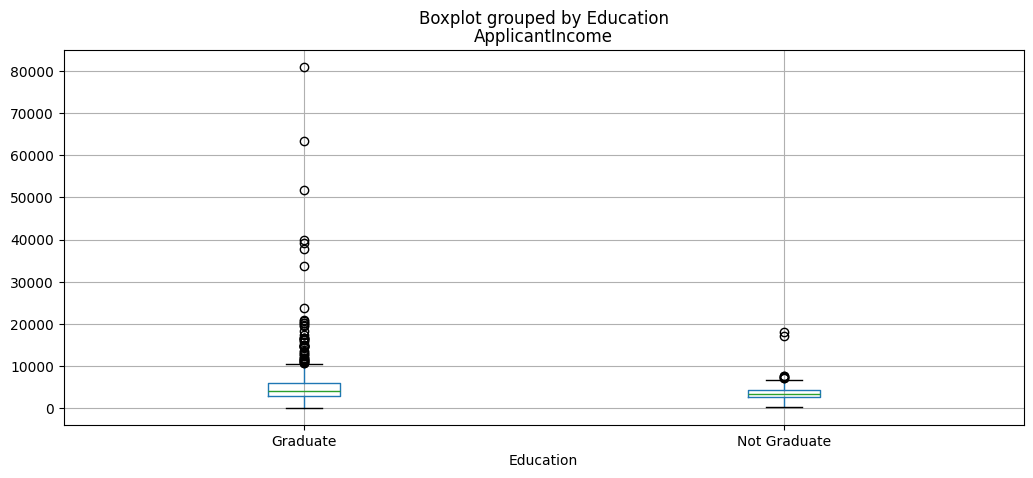

In [ ]:
df.boxplot(column='ApplicantIncome',by = 'Education',figsize = (12,5))
plt.show()

<Axes: >

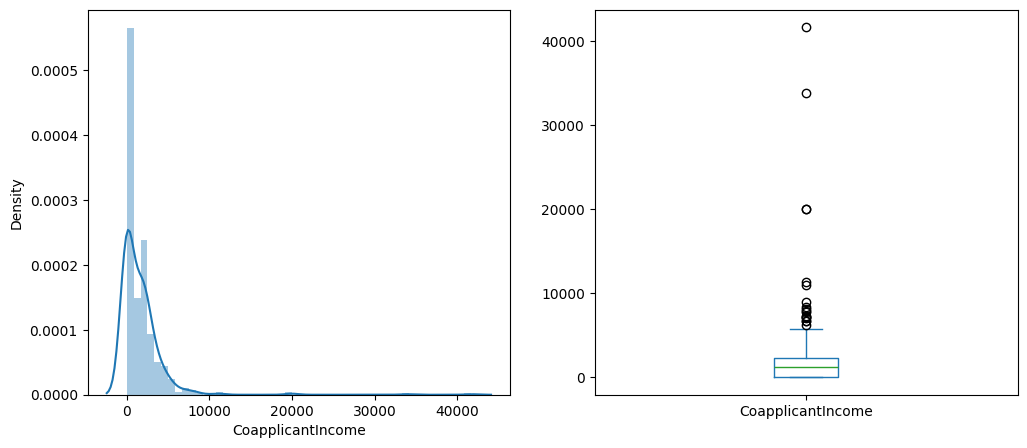

In [ ]:
plt.subplot(121)
sns.distplot(df['CoapplicantIncome'])

plt.subplot(122)
df['CoapplicantIncome'].plot.box(figsize =(12,5))

In [ ]:
df.groupby('Loan_Status')['ApplicantIncome'].mean()

,ApplicantIncome
Loan_Status,
N,5446.078125
Y,5384.068720


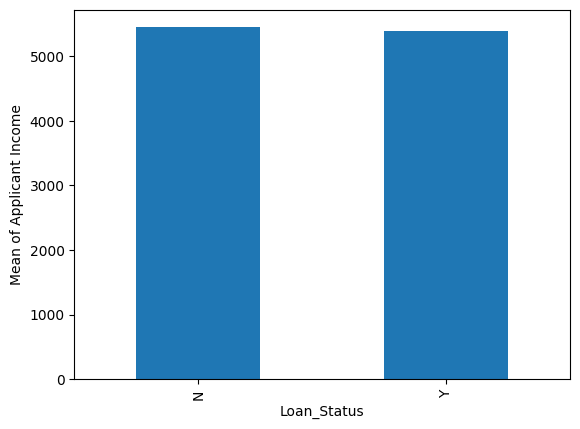

In [ ]:
df.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()
plt.ylabel("Mean of Applicant Income")
plt.show()

Feature Engineer


In [ ]:
# Feature binning: income
bins=[0,2500,4000,6000, 8000, 10000, 20000, 40000, 81000]
group=['Low','Average','medium', 'H1', 'h2', 'h3', 'h4' , 'Very high']
df['Income_bin']= pd.cut(df['ApplicantIncome'],bins,labels=group)

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,medium
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,medium
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,Average
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,Average
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,medium


In [ ]:
pd.crosstab(df["Income_bin"],df["Loan_Status"])

Loan_Status,N,Y
Income_bin,,
Low,34,74
Average,67,159
medium,45,98
H1,20,34
h2,9,22
h3,13,27
h4,3,6
Very high,1,2


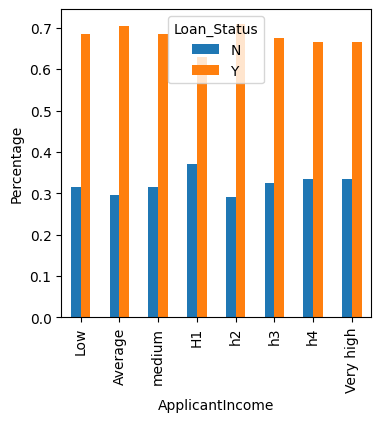

In [ ]:
Income_bin = pd.crosstab(df["Income_bin"],df["Loan_Status"])

Income_bin.div(Income_bin.sum(axis=1),axis=0).plot(kind="bar",figsize=(4,4))
plt.xlabel("ApplicantIncome")
plt.ylabel("Percentage")
plt.show()

In [ ]:
#co-appplicant income
bins=[0,1000,3000,42000]
group =['Low','Average','High']
df['CoapplicantIncome_bin']=pd.cut(df["CoapplicantIncome"],bins,labels=group)

In [ ]:
pd.crosstab(df["CoapplicantIncome_bin"],df["Loan_Status"])

Loan_Status,N,Y
CoapplicantIncome_bin,,
Low,3,19
Average,61,161
High,32,65


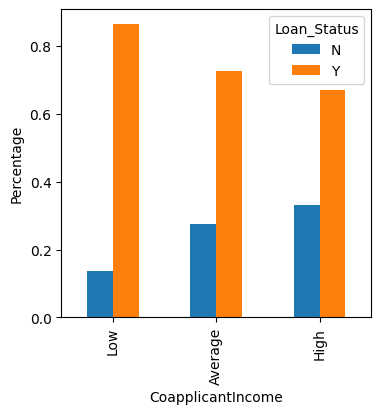

In [ ]:
CoapplicantIncome_Bin = pd.crosstab(df["CoapplicantIncome_bin"],df["Loan_Status"])
CoapplicantIncome_Bin.div(CoapplicantIncome_Bin.sum(axis = 1),axis=0).plot(kind='bar',figsize=(4,4))
plt.xlabel("CoapplicantIncome")
plt.ylabel("Percentage")
plt.show()

In [ ]:
# New feature:  total household income
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

In [ ]:
bins = [0,3000,5000,8000,81000]
group = ['Low','Average','High','Very High']
df["TotalIncome_bin"] = pd.cut(df["TotalIncome"],bins,labels=group)

In [ ]:
pd.crosstab(df["TotalIncome_bin"], df["Loan_Status"])

Loan_Status,N,Y
TotalIncome_bin,,
Low,20,27
Average,69,154
High,61,151
Very High,42,90


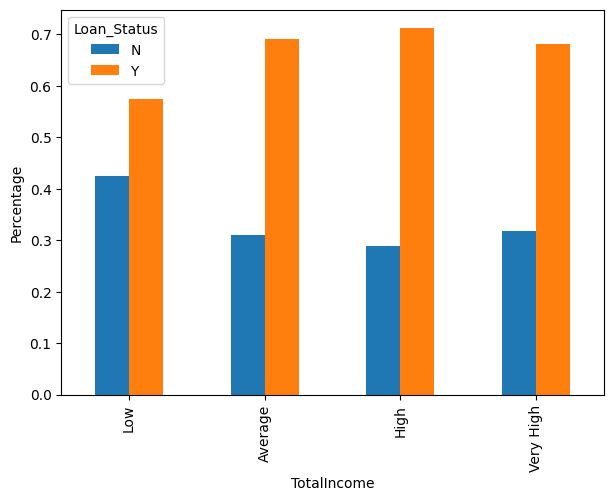

In [ ]:
TotalIncome = pd.crosstab(df["TotalIncome_bin"],df["Loan_Status"])
TotalIncome.div(TotalIncome.sum(axis = 1),axis=0).plot(kind='bar', figsize=(7,5))
plt.xlabel("TotalIncome")
plt.ylabel("Percentage")
plt.show()

# Observation: We can see that Proportion of loans getting approved for
# applicants having low Total_Income is very less as compared to that of applicants
# with Average, High and Very High Income.

In [ ]:
df = df.drop(["Income_bin","CoapplicantIncome_bin","TotalIncome_bin"],axis=1)

Loan Amount and Loan Term

In [12]:
df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [14]:
df['Loan_Amount_Term'] = (df['Loan_Amount_Term']/12).astype('float')

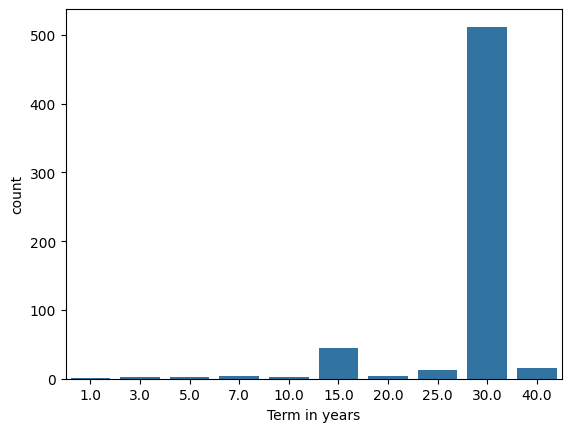

In [17]:
sns.countplot(x='Loan_Amount_Term', data=df)
plt.xlabel("Term in years")
plt.show()
# we can observe that 90% of the loans were applied for 30 yrs


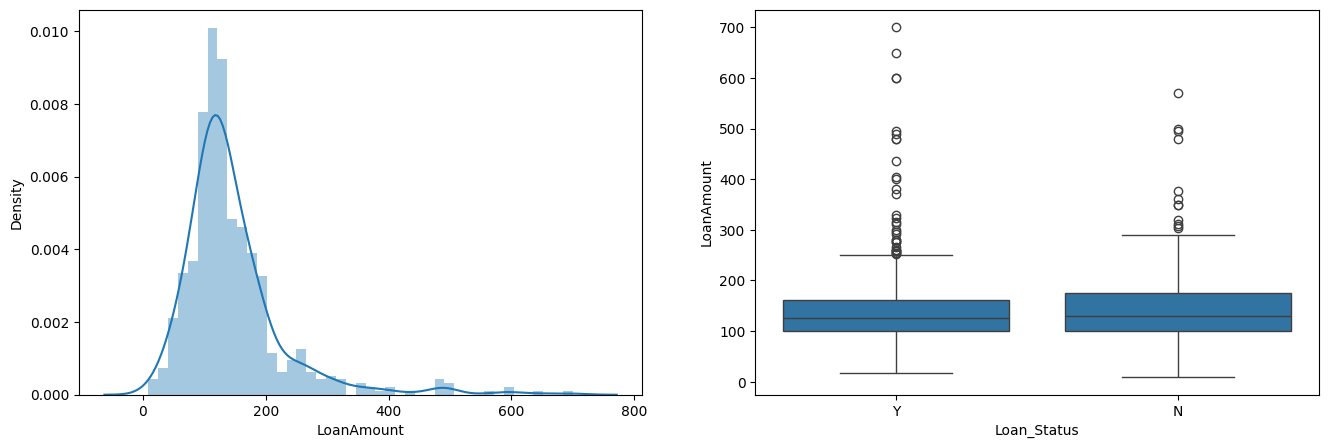

In [19]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['LoanAmount']);

plt.subplot(122)
sns.boxplot(data=df, x='Loan_Status', y = 'LoanAmount')

plt.show()

In [22]:
# Approximate calc: ignoring interest rates as we dont know that.
df['Loan_Amount_per_year']  = df['LoanAmount']/df['Loan_Amount_Term']
